# City-level spatial alignment


In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd() / "figure-reproduction", Path.cwd().parent]
repro_dir = next(
    (path.resolve() for path in candidates if (path / "src").is_dir() and (path / "data").is_dir()),
    None,
)
if repro_dir is None:
    raise FileNotFoundError("Run this notebook from the repository, figure-reproduction, or notebooks directory.")
sys.path.insert(0, str(repro_dir / "src"))

from figure_style import (
    DATA_DIR,
    OUTPUT_DIR,
    close_and_report,
    configure_style,
    figure_size,
    finish_axes,
    save_figure,
)


Matplotlib is building the font cache; this may take a moment.


rendered pixels: 1181 x 1476
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_alignment_ridgeline.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_alignment_ridgeline.pdf


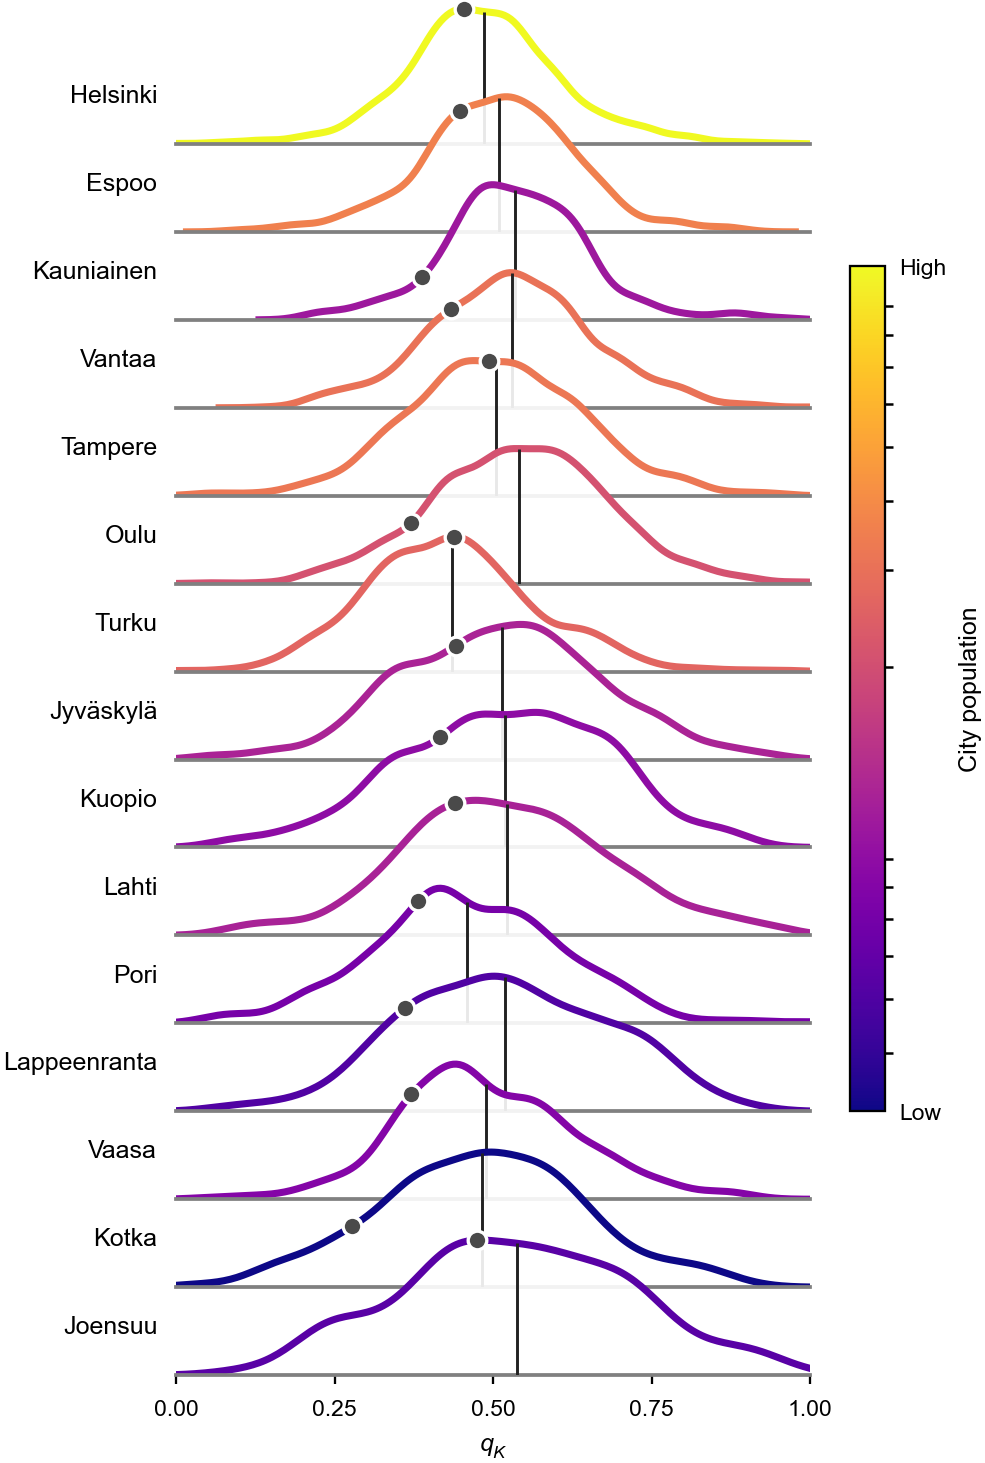

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

EXPORT_PROFILE = "final"
configure_style(EXPORT_PROFILE)

data = pd.read_parquet(DATA_DIR / "spatial_alignment_by_city.parquet")
city_order = (
    data[["name", "city_order"]].drop_duplicates().sort_values("city_order")["name"].tolist()
)
data["name"] = pd.Categorical(data["name"], categories=city_order, ordered=True)

cmap = mpl.colormaps["plasma"]
city_population = data.groupby("name", observed=True)["city_population"].first()
norm = mpl.colors.LogNorm(city_population.min(), city_population.max())
city_colors = {city: cmap(norm(city_population.loc[city])) for city in city_order}

fig = plt.figure(figsize=figure_size("spatial_alignment"))
grid = fig.add_gridspec(
    len(city_order), 2, width_ratios=[1, 0.055], hspace=-0.38,
    left=0.31, right=0.91, bottom=0.055, top=0.985, wspace=0.12,
)
axes = [fig.add_subplot(grid[index, 0]) for index in range(len(city_order))]

for index, (ax, city) in enumerate(zip(axes, city_order)):
    values = data.loc[data["name"].eq(city), "qk_weighted"].dropna()
    sns.kdeplot(
        x=values, bw_adjust=0.8, clip=(0, 1), color="white",
        fill=True, alpha=0.9, linewidth=0, ax=ax,
    )
    sns.kdeplot(
        x=values, bw_adjust=0.8, clip=(0, 1), color=city_colors[city],
        fill=False, linewidth=1.7, ax=ax,
    )
    kde_line = ax.lines[-1]
    ax.axhline(0, color="#808080", linewidth=0.9, clip_on=False)
    city_mean = values.mean()
    mean_height = np.interp(city_mean, kde_line.get_xdata(), kde_line.get_ydata())
    ax.vlines(city_mean, 0, mean_height, color="#222222", linewidth=0.7, zorder=8)

    representative = data[data["name"].eq(city) & data["is_representative"]]
    if not representative.empty:
        point_x = representative.iloc[0]["qk"]
        point_y = np.interp(point_x, kde_line.get_xdata(), kde_line.get_ydata())
        ax.scatter(
            point_x, point_y, s=20, color="#4a4a4a", edgecolor="white",
            linewidth=0.8, zorder=20, clip_on=False,
        )

    ax.text(-0.03, 0.34, city, transform=ax.transAxes, ha="right", va="center", fontsize=6)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.patch.set_alpha(0)
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(False)
    if index != len(axes) - 1:
        ax.tick_params(axis="x", labelbottom=False, bottom=False)
    else:
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xlabel(r"$q_K$", fontsize=6)

color_ax = fig.add_subplot(grid[3:12, 1])
mpl.colorbar.ColorbarBase(color_ax, cmap=cmap, norm=norm, orientation="vertical")
color_ax.set_yticks([city_population.min(), city_population.max()])
color_ax.set_yticklabels(["Low", "High"])
color_ax.set_ylabel("City population", rotation=90, labelpad=3)
color_ax.tick_params(length=0)

paths = save_figure(fig, "spatial_alignment_ridgeline", EXPORT_PROFILE)
close_and_report(fig, paths)
